### Spam Message Classification Using NLP

### Objective

Build a Natural Language Processing (NLP) binary classifier that distinguishes
spam messages from legitimate (ham) messages.

### Tech Stack

- Python
- pandas
- NumPy
- scikit-learn
- NLTK
- matplotlib
- seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)


In [7]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.shape

(5572, 5)

In [9]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [11]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [12]:
df=df[["v1","v2"]]

In [14]:
df.columns=["label","message"]

In [15]:
df.head(5)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df.tail(5)


,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [17]:
df.sample(10)

,label,message
1653,ham,I was at bugis juz now wat... But now i'm walk...
5446,ham,I am back. Good journey! Let me know if you ne...
976,ham,Ok i shall talk to him
4156,ham,This single single answers are we fighting? Pl...
4893,ham,Convey my regards to him
5102,spam,This msg is for your mobile content order It h...
4988,ham,So your telling me I coulda been your real Val...
4015,ham,In which place i can get rooms cheap:-)
71,ham,Finished class where are you.
1872,ham,Oh ok i didnt know what you meant. Yep i am ba...


In [18]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(403)

In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [24]:
df["label"].value_counts(normalize=True)*100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

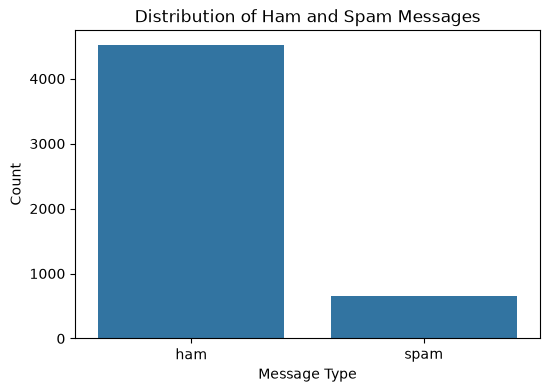

In [25]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

### Class Distribution

The dataset contains two classes:

- Ham: legitimate messages
- Spam: unwanted/promotional/fraudulent messages

The dataset is imbalanced because the number of ham messages is significantly
higher than the number of spam messages.

Therefore, accuracy alone should not be used to judge the model.
Precision, recall, and F1-score are also important.

In [26]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [27]:
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [28]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [29]:
stop_words = set(stopwords.words("english"))

In [32]:
stemmer=PorterStemmer()

### CREATING PREPROCESSSING FUNCTION:

In [34]:
def preprocess_text(text):
    
# Convert to lowercase
    text = text.lower()
    
# Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
# Keep only alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)   
# Split into words
    words = text.split()    
 # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
 # Apply stemming
    words = [
        stemmer.stem(word)
        for word in words
    ]
    
    return " ".join(words)

In [35]:
sample = df["message"].iloc[2]

print("Original:")
print(sample)

print("\nProcessed:")
print(preprocess_text(sample))

Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Processed:
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


In [36]:
df["clean_message"] = df["message"].apply(preprocess_text)

In [37]:
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


### TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

Machine-learning models cannot directly understand raw text. TF-IDF converts
text into numerical features.

TF-IDF gives a higher weight to words that are important in a particular
document but occur less frequently across the entire collection of documents.

It consists of two main ideas:

1. Term Frequency (TF):
   Measures how frequently a word occurs in a particular document.

2. Inverse Document Frequency (IDF):
   Reduces the importance of words that occur in many documents.

Therefore, TF-IDF helps the model focus on words that are more informative
for distinguishing spam from ham messages.

For example, words such as "free", "winner", "claim", "prize", and "urgent"
may receive useful weights if they are characteristic of spam messages.

In [38]:
X = df["clean_message"]
y = df["label_num"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

We used stratify, because our dataset is imbalanced.
We want both training and testing data to maintain approximately the same:

In [40]:
tfidf = TfidfVectorizer()

In [41]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [42]:
X_test_tfidf = tfidf.transform(X_test)

In [43]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 6117)
Testing shape: (1034, 6117)


### MODEL1: NAIVE BAYES:

In [44]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3613., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 6117)","[[0.35,1.34,0.1 ,...,0.3 ,0. ,0.17], [0. ,0. ,0. ,...,0. ,0.35,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 6117)","[[-9.32,-8.77,-9.53,...,-9.36,-9.62,-9.46], [-8.98,-8.98,-8.98,...,-8.98,-8.68,-8.98]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6117


In [45]:
nb_predictions = nb_model.predict(
    X_test_tfidf
)

### ACCURACY:

In [46]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

### PRECISION:

In [47]:
nb_precision = precision_score(
    y_test,
    nb_predictions
)

### RECALL:

In [48]:
nb_recall = recall_score(
    y_test,
    nb_predictions
)

### F1_SCORE:

In [49]:
nb_f1 = f1_score(
    y_test,
    nb_predictions
)


In [50]:
print("Multinomial Naive Bayes")
print("-----------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Multinomial Naive Bayes
-----------------------
Accuracy : 0.965183752417795
Precision: 0.9896907216494846
Recall   : 0.732824427480916
F1 Score : 0.8421052631578947


In [51]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



### MODEL2:LOGISTIC REGRESSION:

In [52]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [53]:
lr_model.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [54]:
lr_predictions = lr_model.predict(
    X_test_tfidf
)

In [55]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions
)

lr_recall = recall_score(
    y_test,
    lr_predictions
)

lr_f1 = f1_score(
    y_test,
    lr_predictions
)

In [56]:
print("Logistic Regression")
print("-------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
-------------------
Accuracy : 0.9613152804642167
Precision: 1.0
Recall   : 0.6946564885496184
F1 Score : 0.8198198198198198


### COMPARING TWO MODELS:

In [57]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.965184,0.989691,0.732824,0.842105
1,Logistic Regression,0.961315,1.000000,0.694656,0.819820


### Model Selection

After comparing Multinomial Naive Bayes and Logistic Regression, **Multinomial
Naive Bayes was selected as the final model** for spam classification.
Naive Bayes achieved better spam recall, correctly identifying more actual
spam messages while keeping false positives very low.
Since detecting as many spam messages as possible is important in this task,
Naive Bayes is considered the more suitable model for this dataset.

### Why is Recall Important for Spam Detection?

Recall measures how many of the actual spam messages are correctly identified
as spam.

In spam detection, a false negative occurs when an actual spam message is
classified as ham.

For example, if a phishing or fraudulent message is incorrectly classified
as legitimate, the user may open the message, click a malicious link, or
provide sensitive information.

Therefore, high recall is important because it helps the model detect as
many actual spam messages as possible.

However, precision is also important because incorrectly marking legitimate
messages as spam can cause users to miss important messages.

Therefore, a good spam classifier should aim for a strong balance between
precision and recall, which can be summarized using the F1-score.

### CONFUSION MATRIX:

In [58]:
cm_nb = confusion_matrix(
    y_test,
    nb_predictions
)

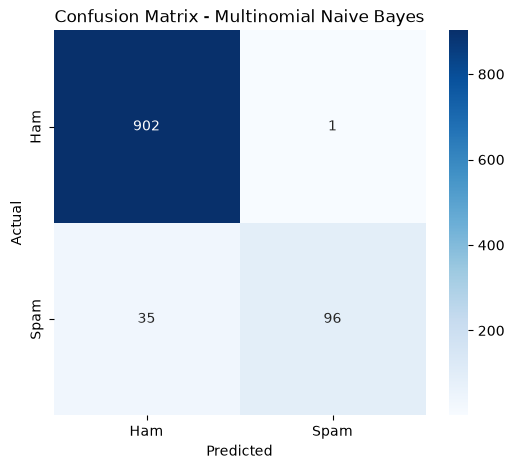

In [59]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

### Confusion Matrix - Multinomial Naive Bayes

The confusion matrix shows that the model correctly classified **902 ham** and **96 spam** messages.  
Only **1 ham message** was incorrectly classified as spam, resulting in a very low number of false positives.  
However, **35 spam messages** were incorrectly classified as ham, which are false negatives.  
The model therefore detects most spam messages but still misses some actual spam.  
Since spam detection requires identifying as many spam messages as possible, **recall is particularly important**.  
Overall, the model shows good performance with a strong ability to distinguish between ham and spam messages.

### CONFUSION MATRIX FOR LOGISTIC REGRESSION:

In [60]:
cm_lr = confusion_matrix(
    y_test,
    lr_predictions
)

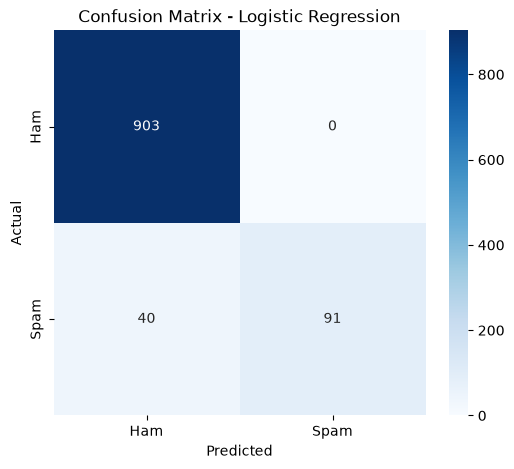

In [61]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified 903 ham messages and 91 spam messages. It incorrectly classified 40 spam messages as ham, while no ham messages were classified as spam. Therefore, the model has zero false positives, but it has 40 false negatives. This means the model has good precision but its spam recall can be improved because some spam messages are being missed.

In [69]:
from wordcloud import WordCloud

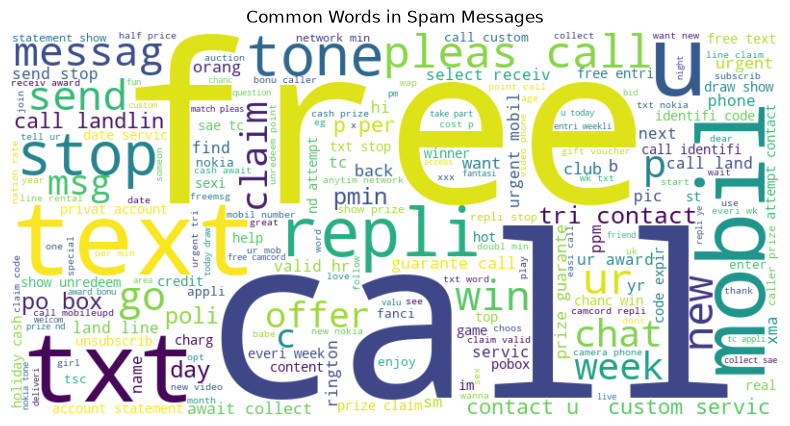

In [70]:
spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    spam_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Common Words in Spam Messages")

plt.show()

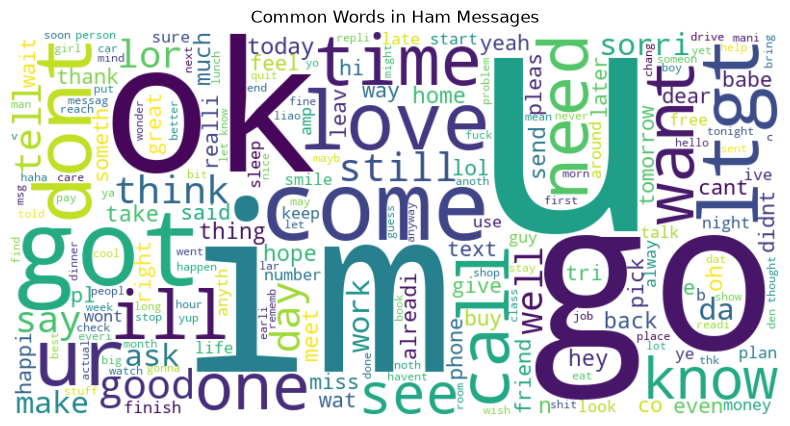

In [71]:
ham_text = " ".join(
    df[df["label"] == "ham"]["clean_message"]
)

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    ham_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Common Words in Ham Messages")

plt.show()

In [66]:
def predict_message(message):
    
    cleaned = preprocess_text(message)
    
    vectorized = tfidf.transform([cleaned])
    
    prediction = nb_model.predict(vectorized)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

In [67]:
message = "Congratulations! You won a free prize. Claim now!"
print(predict_message(message))

Spam


In [68]:
message = "Hey, are you coming to college tomorrow?"
print(predict_message(message))

Ham


### Conclusion

In this project, an NLP-based binary classification system was developed to
distinguish spam messages from legitimate ham messages.

The dataset was cleaned by removing unnecessary columns, checking missing
values and duplicates, and preprocessing the message text.

Text data was converted into numerical features using TF-IDF Vectorization.

Two machine-learning classifiers were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

The models were evaluated using accuracy, precision, recall, F1-score, and
confusion matrices.

Recall was given particular importance because failing to detect an actual
spam message can expose users to unwanted or potentially harmful content.

The model with the strongest overall evaluation metrics was selected as the
preferred classifier.